# Molecular prediction along the m/z axis (axis-200-900)

Head metrics per 100 Da class window show which m/z regions are predicted well or poorly, and whether held-out images degrade uniformly or in specific regions.

## Introduction

Classes are grouped by the window of their annotated m/z (median over datasets). Macro metrics per window
average over the eligible classes of the window; micro precision/recall pool their confusion counts.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* The head was trained with the variational PU loss: annotations are positive, missing annotations are unlabelled.
  `annotation_retrieval` therefore treats unlabelled entries as negatives and underestimates precision when
  annotations are incomplete; `operational_pn` removes entries with signal but no annotation.
* Threshold metrics use $\hat Y \ge 0.5$; VPU logits are treated as 0.5-anchored as in the earlier head analyses.
* Evaluations: `train`, `test`, `test_extended`, `test_combined` (test and extension together, the main per-class
  estimate for rare classes) and `heldout_image`.

        * Windows hold very different numbers of classes; windows with few eligible classes have noisy macro values.
          The class counts are listed below.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Ranking populations: `annotation_retrieval` (every available entry; annotated = positive, everything else
  negative) and `operational_pn` (only evidence positives P and operational negatives N; unlabelled entries with
  signal at the ion's bins, U, are excluded). Evidence rule: peak above 1.19 % of the spectrum maximum within
  +/- 1 bin.
* AP: average precision per class; macro = mean over eligible classes (at least one positive and one negative in
  the evaluated population and training support); micro = one ranking over all eligible entries.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "prediction_local"
AXIS = "axis-200-900"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

EVALUATIONS = ['train', 'test', 'test_combined', 'heldout_image']
EVALUATION_COLORS = {name: POPULATION_COLORS[name] for name in EVALUATIONS}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'micro_prevalence', 'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1',
                'hamming_loss']


def metric_table(frame, index, columns, column_order):
    """Mean +/- SD over repetitions of every metric of a long table (`metric`, `value`)."""
    long = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).copy()
    long['metric'] = pd.Categorical(long.metric, categories=[name for name in METRIC_ORDER if name in set(long.metric)], ordered=True)
    grouped = long.groupby([*index, 'metric', columns], observed=True).value
    cells = grouped.mean().map('{:.4f}'.format) + ' +/- ' + grouped.std().map('{:.4f}'.format)
    shown = cells.unstack(columns)
    return shown[[name for name in column_order if name in shown.columns]]


def metric_columns_table(frame, index):
    """Mean +/- SD over repetitions of every metric column of a wide table."""
    columns = [name for name in METRIC_ORDER if name in frame.columns]
    grouped = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).groupby(index)[columns]
    return grouped.mean().round(4).astype(str) + ' +/- ' + grouped.std().round(4).astype(str)

windows = table('window_metrics')
windows = windows[windows.group == 'all']

Analysis: prediction_local | axis: axis-200-900 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 200-900 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`prediction_local` groups the per-class ranking tables of the `inference` level by class m/z window.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis prediction_local > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Macro AP per m/z window (annotation retrieval)

### Methodology

#### Theoretical

The macro AP per window compares the prediction quality of m/z regions; the lines of different evaluation
populations show whether the degradation to new pixels or images is uniform along m/z.

#### Implementation

`window_metrics` rows of ranking population `annotation_retrieval`.

#### Figure descriptions

x = window lower edge (m/z), y = macro AP, micro AP and micro recall at 0.5 (three figures); colour = evaluation population, one line per repetition.

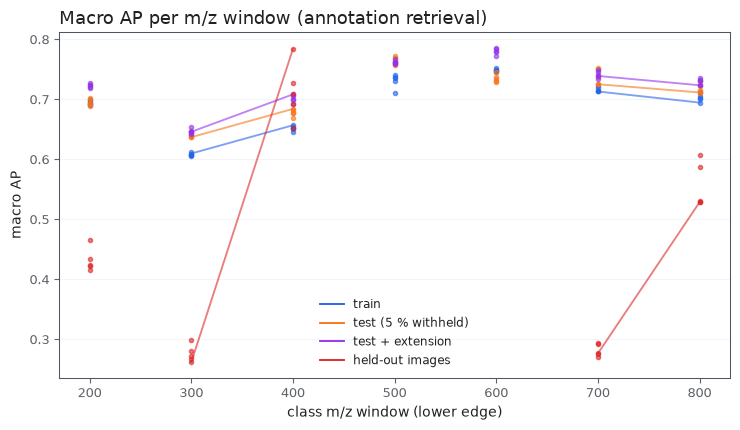

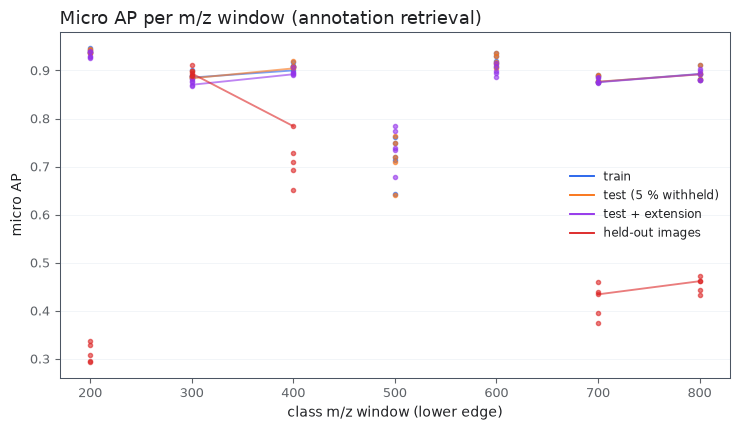

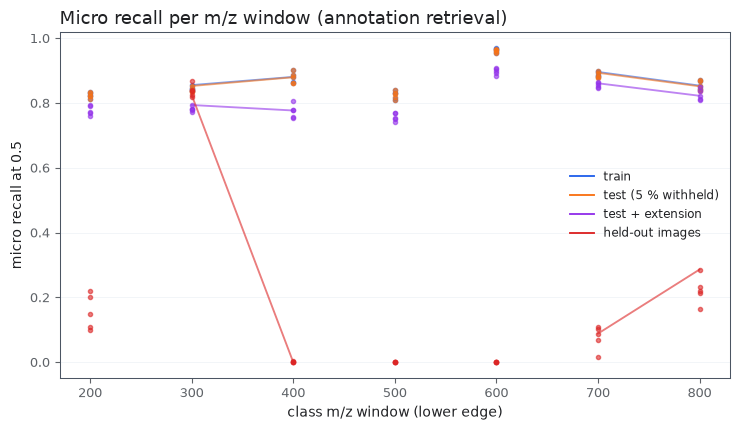

In [3]:
shown = windows[windows.population == 'annotation_retrieval']
figures.line_by_repetition(shown, x='mz_window_lower', y='average_precision', color_by='evaluation', levels=EVALUATIONS, colors=EVALUATION_COLORS, xlabel='class m/z window (lower edge)', ylabel='macro AP', title='Macro AP per m/z window (annotation retrieval)', theme=theme);
figures.line_by_repetition(shown, x='mz_window_lower', y='micro_average_precision', color_by='evaluation', levels=EVALUATIONS, colors=EVALUATION_COLORS, xlabel='class m/z window (lower edge)', ylabel='micro AP', title='Micro AP per m/z window (annotation retrieval)', theme=theme);
figures.line_by_repetition(shown, x='mz_window_lower', y='micro_recall', color_by='evaluation', levels=EVALUATIONS, colors=EVALUATION_COLORS, xlabel='class m/z window (lower edge)', ylabel='micro recall at 0.5', title='Micro recall per m/z window (annotation retrieval)', theme=theme);

### Remarks

- On test the window AP ranges from 0.64 (300-400) to 0.77 (500-600); held-out values are defined only in windows with held-out annotations (1-7 eligible classes) and range 0.28-0.71.

### Notes

## Macro AP per m/z window (operational P/N)

### Methodology

#### Theoretical

The macro AP per window compares the prediction quality of m/z regions; the lines of different evaluation
populations show whether the degradation to new pixels or images is uniform along m/z.

#### Implementation

`window_metrics` rows of ranking population `operational_pn`.

#### Figure descriptions

x = window lower edge (m/z), y = macro AP, micro AP and micro recall at 0.5 (three figures); colour = evaluation population, one line per repetition.

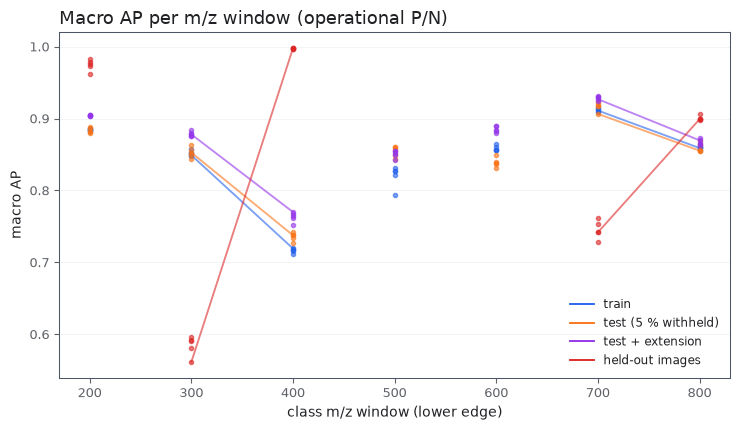

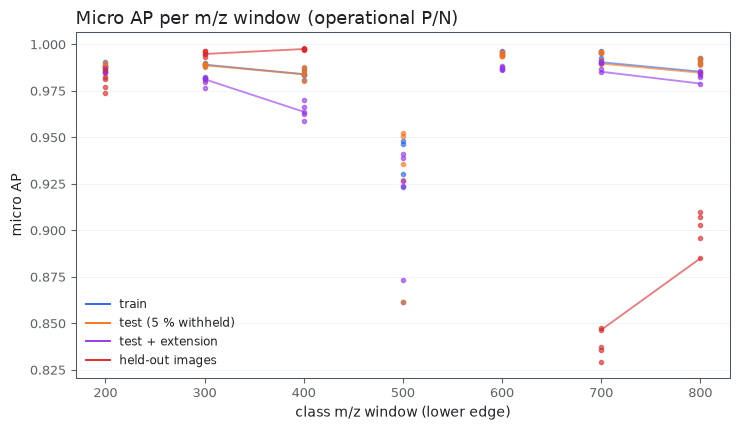

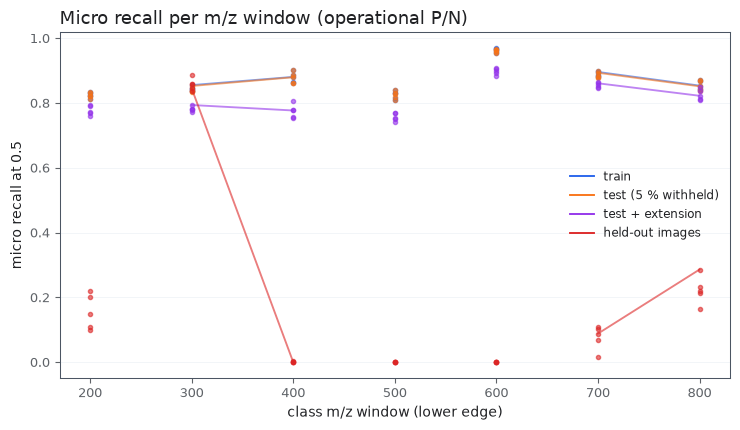

In [4]:
shown = windows[windows.population == 'operational_pn']
figures.line_by_repetition(shown, x='mz_window_lower', y='average_precision', color_by='evaluation', levels=EVALUATIONS, colors=EVALUATION_COLORS, xlabel='class m/z window (lower edge)', ylabel='macro AP', title='Macro AP per m/z window (operational P/N)', theme=theme);
figures.line_by_repetition(shown, x='mz_window_lower', y='micro_average_precision', color_by='evaluation', levels=EVALUATIONS, colors=EVALUATION_COLORS, xlabel='class m/z window (lower edge)', ylabel='micro AP', title='Micro AP per m/z window (operational P/N)', theme=theme);
figures.line_by_repetition(shown, x='mz_window_lower', y='micro_recall', color_by='evaluation', levels=EVALUATIONS, colors=EVALUATION_COLORS, xlabel='class m/z window (lower edge)', ylabel='micro recall at 0.5', title='Micro recall per m/z window (operational P/N)', theme=theme);

### Remarks

### Notes

## Complete metric set per m/z window

### Methodology

#### Theoretical

Every metric of the whole-axis table is computed per window by running the ranking evaluation on the classes
of the window only, so micro AP, micro ROC AUC and the Hamming loss are exact per window (not derived from the
macro values).

#### Implementation

`window_metrics` rows of ranking population `annotation_retrieval`, every evaluation population.

#### Figure descriptions

No figure; one table per evaluation population: rows = window, columns = metrics (mean +/- SD over repetitions).

In [5]:
retrieval = windows[windows.population == 'annotation_retrieval']
for evaluation in EVALUATIONS:
    print(evaluation)
    display(metric_columns_table(retrieval[retrieval.evaluation == evaluation], ['mz_window_lower', 'stratum']))

train


,,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,micro_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,hamming_loss
mz_window_lower,stratum,,,,,,,,,,,,,
200.0,200-300,0.6949 +/- 0.0034,0.9409 +/- 0.0041,0.9936 +/- 0.0001,0.9975 +/- 0.0002,0.6511 +/- 0.0034,0.0438 +/- 0.0,0.6221 +/- 0.0304,0.4811 +/- 0.0133,0.4818 +/- 0.0221,0.9119 +/- 0.0056,0.8248 +/- 0.0079,0.8662 +/- 0.0066,0.0112 +/- 0.0005
300.0,300-400,0.6086 +/- 0.0029,0.8901 +/- 0.0058,0.993 +/- 0.0003,0.997 +/- 0.0002,0.573 +/- 0.0029,0.0356 +/- 0.0,0.5267 +/- 0.0279,0.4711 +/- 0.0186,0.4536 +/- 0.0086,0.8682 +/- 0.0047,0.8443 +/- 0.0074,0.8561 +/- 0.0026,0.0101 +/- 0.0002
400.0,400-500,0.652 +/- 0.004,0.9082 +/- 0.0063,0.9938 +/- 0.0002,0.9973 +/- 0.0002,0.6112 +/- 0.004,0.0408 +/- 0.0,0.5015 +/- 0.0376,0.4055 +/- 0.0313,0.4163 +/- 0.0262,0.9064 +/- 0.0044,0.8791 +/- 0.0162,0.8925 +/- 0.0084,0.0086 +/- 0.0006
500.0,500-600,0.7309 +/- 0.0119,0.7173 +/- 0.0463,0.9862 +/- 0.0006,0.9904 +/- 0.0012,0.6883 +/- 0.0119,0.0426 +/- 0.0,0.6536 +/- 0.0112,0.5203 +/- 0.0097,0.5257 +/- 0.0092,0.7127 +/- 0.01,0.8257 +/- 0.0122,0.7649 +/- 0.0045,0.0216 +/- 0.0005
600.0,600-700,0.7489 +/- 0.002,0.9212 +/- 0.0116,0.9864 +/- 0.0001,0.9948 +/- 0.0006,0.6758 +/- 0.002,0.0731 +/- 0.0,0.6376 +/- 0.0304,0.6784 +/- 0.0217,0.6018 +/- 0.0132,0.7356 +/- 0.0053,0.9639 +/- 0.006,0.8344 +/- 0.0034,0.028 +/- 0.0006
700.0,700-800,0.7166 +/- 0.0042,0.8812 +/- 0.007,0.9876 +/- 0.0003,0.9925 +/- 0.0002,0.6345 +/- 0.0042,0.0821 +/- 0.0,0.6142 +/- 0.0355,0.552 +/- 0.022,0.5351 +/- 0.0194,0.8343 +/- 0.0044,0.8888 +/- 0.0087,0.8607 +/- 0.0021,0.0236 +/- 0.0002
800.0,800-900,0.7029 +/- 0.0064,0.892 +/- 0.012,0.9868 +/- 0.0003,0.9935 +/- 0.0005,0.6351 +/- 0.0064,0.0678 +/- 0.0,0.5959 +/- 0.0367,0.5172 +/- 0.0313,0.5019 +/- 0.0205,0.82 +/- 0.0176,0.8553 +/- 0.0143,0.8371 +/- 0.0076,0.0226 +/- 0.0012


test


,,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,micro_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,hamming_loss
mz_window_lower,stratum,,,,,,,,,,,,,
200.0,200-300,0.6956 +/- 0.006,0.9395 +/- 0.0042,0.993 +/- 0.0001,0.9974 +/- 0.0002,0.6517 +/- 0.006,0.0439 +/- 0.0,0.5797 +/- 0.031,0.4862 +/- 0.0122,0.4793 +/- 0.0202,0.9109 +/- 0.006,0.8239 +/- 0.0083,0.8652 +/- 0.007,0.0113 +/- 0.0006
300.0,300-400,0.6402 +/- 0.0034,0.8884 +/- 0.0061,0.9903 +/- 0.0013,0.997 +/- 0.0002,0.6043 +/- 0.0034,0.0358 +/- 0.0,0.5074 +/- 0.0192,0.465 +/- 0.0182,0.4542 +/- 0.0116,0.8684 +/- 0.0045,0.8406 +/- 0.0073,0.8543 +/- 0.0028,0.0103 +/- 0.0002
400.0,400-500,0.6784 +/- 0.0059,0.9096 +/- 0.0057,0.9936 +/- 0.0003,0.9973 +/- 0.0002,0.6374 +/- 0.0059,0.0409 +/- 0.0,0.462 +/- 0.0242,0.4039 +/- 0.0321,0.4135 +/- 0.0267,0.9044 +/- 0.0047,0.8779 +/- 0.0177,0.8909 +/- 0.0094,0.0088 +/- 0.0007
500.0,500-600,0.7647 +/- 0.0061,0.7163 +/- 0.0478,0.9856 +/- 0.0005,0.9903 +/- 0.0012,0.7219 +/- 0.0061,0.0427 +/- 0.0,0.6383 +/- 0.0236,0.5249 +/- 0.0119,0.528 +/- 0.0131,0.7122 +/- 0.0102,0.8249 +/- 0.012,0.7643 +/- 0.0045,0.0217 +/- 0.0006
600.0,600-700,0.7355 +/- 0.0068,0.9207 +/- 0.0124,0.9846 +/- 0.0004,0.9947 +/- 0.0006,0.6623 +/- 0.0068,0.0732 +/- 0.0,0.6283 +/- 0.0312,0.6761 +/- 0.0216,0.6027 +/- 0.0126,0.736 +/- 0.0048,0.9615 +/- 0.0058,0.8337 +/- 0.0024,0.0281 +/- 0.0005
700.0,700-800,0.7381 +/- 0.0133,0.882 +/- 0.0069,0.9869 +/- 0.0005,0.9925 +/- 0.0002,0.6558 +/- 0.0133,0.0823 +/- 0.0,0.5867 +/- 0.0149,0.5506 +/- 0.0214,0.5338 +/- 0.018,0.8346 +/- 0.0045,0.8874 +/- 0.0089,0.8602 +/- 0.0025,0.0237 +/- 0.0003
800.0,800-900,0.7184 +/- 0.0084,0.892 +/- 0.0121,0.9839 +/- 0.0007,0.9934 +/- 0.0005,0.6503 +/- 0.0084,0.068 +/- 0.0,0.5727 +/- 0.0318,0.5185 +/- 0.0285,0.5028 +/- 0.0189,0.8197 +/- 0.0181,0.8547 +/- 0.0143,0.8366 +/- 0.0082,0.0227 +/- 0.0013


test_combined


,,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,micro_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,hamming_loss
mz_window_lower,stratum,,,,,,,,,,,,,
200.0,200-300,0.7229 +/- 0.0032,0.9326 +/- 0.0062,0.9885 +/- 0.0001,0.9954 +/- 0.0004,0.6611 +/- 0.0032,0.0618 +/- 0.0,0.6082 +/- 0.0393,0.4847 +/- 0.0153,0.4886 +/- 0.0237,0.9062 +/- 0.0084,0.7779 +/- 0.0149,0.8371 +/- 0.0121,0.0187 +/- 0.0013
300.0,300-400,0.6471 +/- 0.004,0.8746 +/- 0.006,0.9833 +/- 0.0008,0.9941 +/- 0.0002,0.5997 +/- 0.004,0.0474 +/- 0.0,0.5231 +/- 0.0237,0.4637 +/- 0.018,0.4543 +/- 0.0093,0.8413 +/- 0.0217,0.7813 +/- 0.0078,0.8101 +/- 0.0105,0.0174 +/- 0.0011
400.0,400-500,0.701 +/- 0.0062,0.896 +/- 0.0061,0.9902 +/- 0.0001,0.9955 +/- 0.0004,0.6513 +/- 0.0062,0.0497 +/- 0.0,0.4622 +/- 0.0255,0.3997 +/- 0.0297,0.4128 +/- 0.0285,0.9138 +/- 0.0051,0.775 +/- 0.0212,0.8385 +/- 0.0118,0.0148 +/- 0.0009
500.0,500-600,0.7624 +/- 0.0031,0.7418 +/- 0.0411,0.9859 +/- 0.0003,0.9897 +/- 0.0011,0.7113 +/- 0.0031,0.0511 +/- 0.0,0.6578 +/- 0.0133,0.5154 +/- 0.0153,0.5265 +/- 0.0137,0.7616 +/- 0.0104,0.7568 +/- 0.012,0.7591 +/- 0.007,0.0246 +/- 0.0007
600.0,600-700,0.7803 +/- 0.005,0.9012 +/- 0.0117,0.9886 +/- 0.0001,0.9939 +/- 0.0004,0.7175 +/- 0.005,0.0628 +/- 0.0,0.6289 +/- 0.0313,0.6529 +/- 0.0237,0.5858 +/- 0.0138,0.7413 +/- 0.0048,0.8973 +/- 0.0092,0.8118 +/- 0.0031,0.0261 +/- 0.0004
700.0,700-800,0.742 +/- 0.0058,0.8791 +/- 0.006,0.9878 +/- 0.0003,0.9925 +/- 0.0002,0.6669 +/- 0.0058,0.0752 +/- 0.0,0.6061 +/- 0.03,0.5584 +/- 0.0208,0.5454 +/- 0.0196,0.8399 +/- 0.0049,0.8553 +/- 0.0081,0.8475 +/- 0.0028,0.0231 +/- 0.0004
800.0,800-900,0.7291 +/- 0.0051,0.8907 +/- 0.0105,0.9866 +/- 0.0005,0.9935 +/- 0.0003,0.666 +/- 0.0051,0.0631 +/- 0.0,0.597 +/- 0.033,0.5199 +/- 0.0295,0.5081 +/- 0.0207,0.8288 +/- 0.0152,0.8266 +/- 0.0173,0.8275 +/- 0.0064,0.0217 +/- 0.0008


heldout_image


,,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,micro_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,hamming_loss
mz_window_lower,stratum,,,,,,,,,,,,,
200.0,200-300,0.4322 +/- 0.0197,0.3127 +/- 0.0197,0.5625 +/- 0.0157,0.5685 +/- 0.0179,0.1472 +/- 0.0197,0.285 +/- 0.0,0.447 +/- 0.0234,0.1644 +/- 0.0576,0.234 +/- 0.0616,0.3299 +/- 0.0744,0.1555 +/- 0.0538,0.2102 +/- 0.0635,0.3285 +/- 0.0164
300.0,300-400,0.2765 +/- 0.0146,0.8965 +/- 0.0087,0.8189 +/- 0.0112,0.9753 +/- 0.0013,0.0757 +/- 0.0146,0.2008 +/- 0.0,0.2336 +/- 0.0408,0.1918 +/- 0.0067,0.1941 +/- 0.0081,0.9002 +/- 0.0038,0.8374 +/- 0.0187,0.8676 +/- 0.011,0.0513 +/- 0.0038
400.0,400-500,0.7131 +/- 0.0486,0.7131 +/- 0.0486,0.9628 +/- 0.0076,0.9628 +/- 0.0076,0.5768 +/- 0.0486,0.1363 +/- 0.0,0.4 +/- 0.5477,0.0009 +/- 0.0019,0.0018 +/- 0.0037,0.4 +/- 0.5477,0.0009 +/- 0.0019,0.0018 +/- 0.0037,0.1362 +/- 0.0003
500.0,500-600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,NaN
600.0,600-700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,NaN
700.0,700-800,0.2819 +/- 0.01,0.4207 +/- 0.0353,0.589 +/- 0.0113,0.6941 +/- 0.0068,0.0698 +/- 0.01,0.2121 +/- 0.0,0.3333 +/- 0.0186,0.0333 +/- 0.0147,0.0543 +/- 0.0223,0.6603 +/- 0.1168,0.0768 +/- 0.0377,0.1363 +/- 0.0649,0.2029 +/- 0.0066
800.0,800-900,0.5568 +/- 0.0382,0.4544 +/- 0.0162,0.7687 +/- 0.016,0.6488 +/- 0.0141,0.1658 +/- 0.0382,0.391 +/- 0.0,0.4713 +/- 0.0158,0.3763 +/- 0.0355,0.2807 +/- 0.0417,0.3675 +/- 0.0266,0.2233 +/- 0.0434,0.2768 +/- 0.0406,0.4526 +/- 0.0094


### Remarks

- Micro AP (test + extension) ranges from 0.74 (500-600 m/z) to 0.93 (200-300); on held-out images from 0.31 (200-300, two classes) to 0.90 (300-400).
- Held-out Hamming loss is highest in 800-900 m/z (0.45): its two annotated classes cover most of the tissue and one of them (C47H79O12P|-H) is predicted far below 0.5 (see `part_1_11`).

### Notes

## Classes per window

### Methodology

#### Theoretical

The number of classes and eligible classes per window determines the reliability of every window value.

#### Implementation

`window_metrics` counts (repetition 0, annotation retrieval).

#### Figure descriptions

No figure.

In [6]:
counts = windows[(windows.repetition == 0) & (windows.population == 'annotation_retrieval')]
display(counts.pivot_table(index=['mz_window_lower', 'stratum'], columns='evaluation', values='eligible_classes')[EVALUATIONS])

,evaluation,train,test,test_combined,heldout_image
mz_window_lower,stratum,,,,
200.0,200-300,108.0,108.0,108.0,2.0
300.0,300-400,140.0,140.0,140.0,5.0
400.0,400-500,44.0,44.0,44.0,1.0
500.0,500-600,33.0,33.0,33.0,0.0
600.0,600-700,18.0,18.0,18.0,0.0
700.0,700-800,81.0,81.0,81.0,7.0
800.0,800-900,84.0,84.0,84.0,2.0


### Remarks

- 300-400 (140 classes) and 200-300 (108) hold most classes; held-out windows contain 0-7 eligible classes.

### Notes

## Per-class AP against class m/z

### Methodology

#### Theoretical

Individual classes show whether a poor window is poor for all its classes or only for a few.

#### Implementation

`class_positions`: repetition-mean AP of eligible classes, annotation retrieval.

#### Figure descriptions

x = class m/z, y = repetition-mean AP; colour = class set; left = test + extension, right = held-out images.

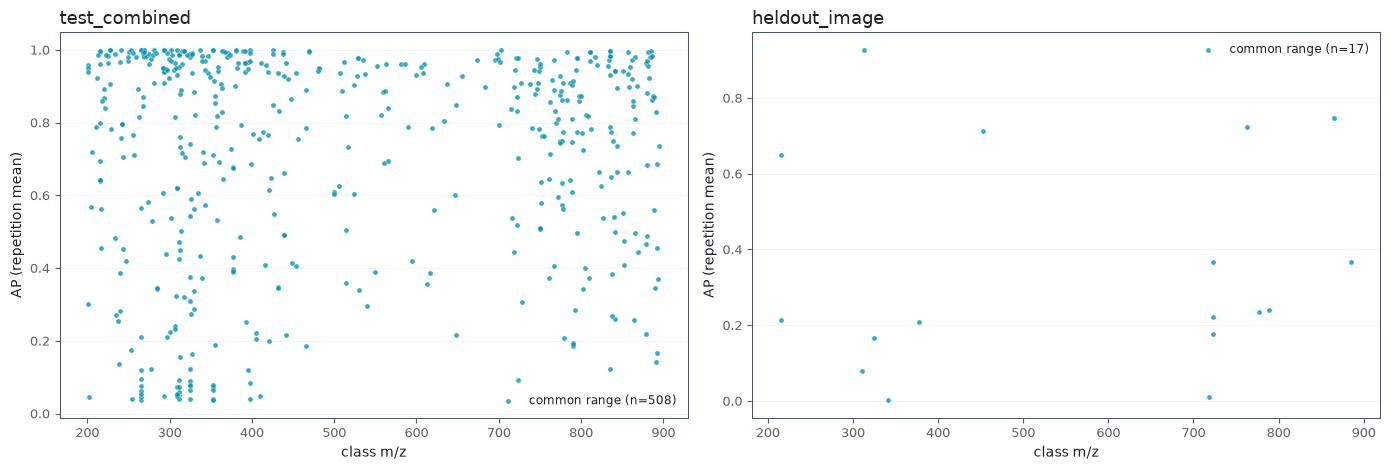

In [7]:
positions = table('class_positions')
positions = positions[(positions.population == 'annotation_retrieval') & positions.eligible.astype(bool)]
means = positions.groupby(['evaluation', 'class_name', 'class_set'], as_index=False).agg(mz=('mz', 'first'), average_precision=('average_precision', 'mean'))
sets = [value for value in figures.CLASS_SET_ORDER if value in set(means.class_set)]
figure, axes = plt.subplots(1, 2, figsize=(14, 4.8), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    figures.paired_scatter(means[means.evaluation == evaluation], x='mz', y='average_precision', hue='class_set', hue_order=sets, xlabel='class m/z', ylabel='AP (repetition mean)', title=evaluation, diagonal=False, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

### Notes

## Results / Summary

### LLM

- **Observed:** on test pixels prediction quality varies moderately along m/z (macro AP 0.64-0.78), lowest in 300-400 m/z where most classes lie.
- **Observed:** the drop on held-out images is present in every window with held-out annotations.
- **Caveat:** held-out window values rest on 1-7 classes and are not reliable individually.

### Person